In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch

In [3]:
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

In [4]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [5]:
all_images = []
for path in image_paths:
    all_images.append(cv2.imread(path))
    cv2.cvtColor(all_images[len(all_images)-1], cv2.COLOR_BGR2RGB)

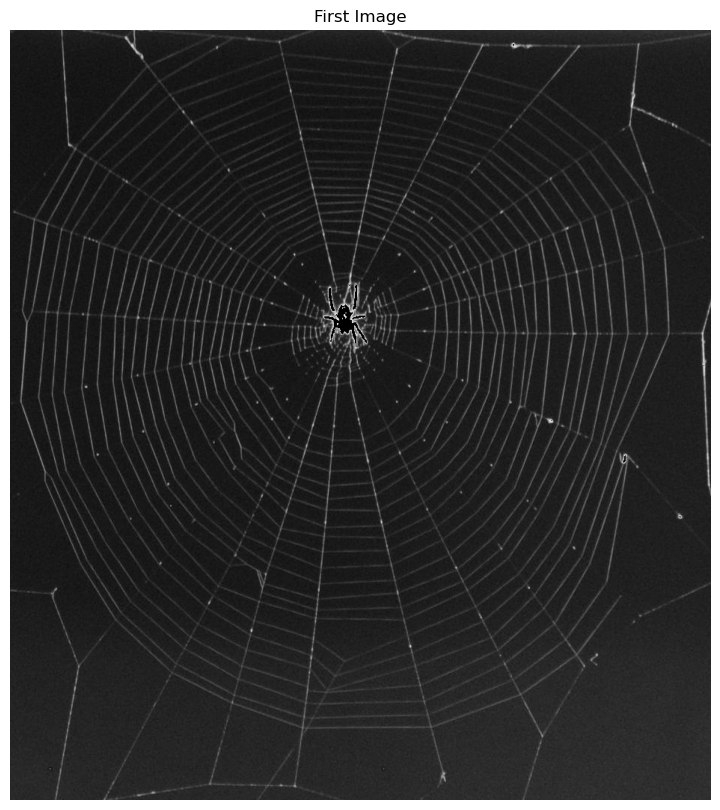

In [6]:
imshow(all_images[0], title = "First Image")

In [113]:
import cv2
import numpy as np

def apply_multi_gabor(gray, orientations=8, ksize=21):
    """
    Apply multiple Gabor filters to enhance line structures in various directions.
    """
    filtered_imgs = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta,
                                    lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC1, kernel)
        filtered_imgs.append(filtered)
    return np.max(filtered_imgs, axis=0)

def enhance_spider_web_smart2(gray_image):
    """
    Smarter enhancement: Tophat + multi-orientation Gabor filters + CLAHE.
    Designed to target spider web geometries more robustly.
    """
    gray = gray_image.copy()

    # Step 1: Morphological tophat
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,5))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # Step 2: Gabor filters for radial/circular lines
    gabor_enhanced = apply_multi_gabor(tophat, orientations=12, ksize=25)
    imshow(gabor_enhanced, title = "gabor_enhanced")
    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    final = clahe.apply(gabor_enhanced)

    return final


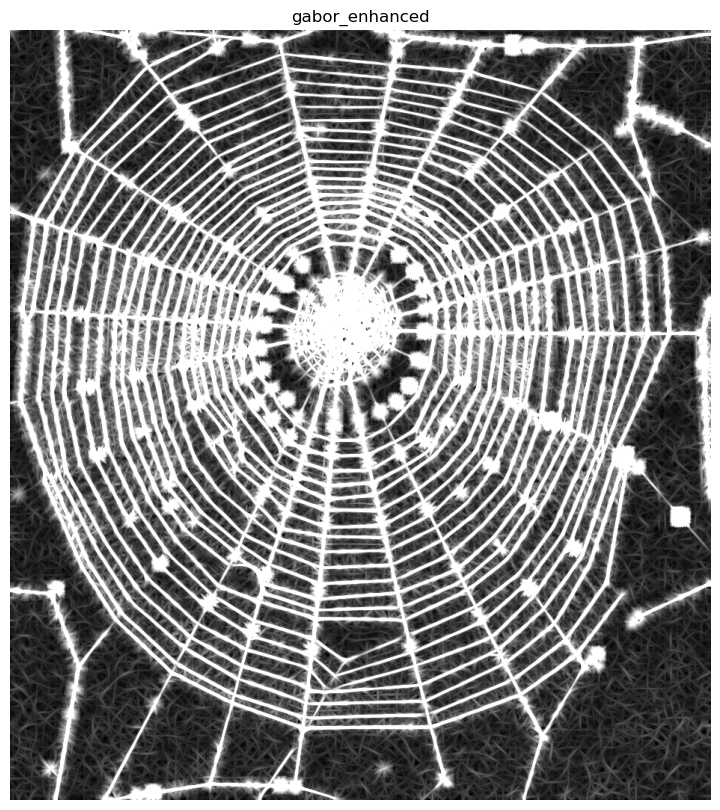

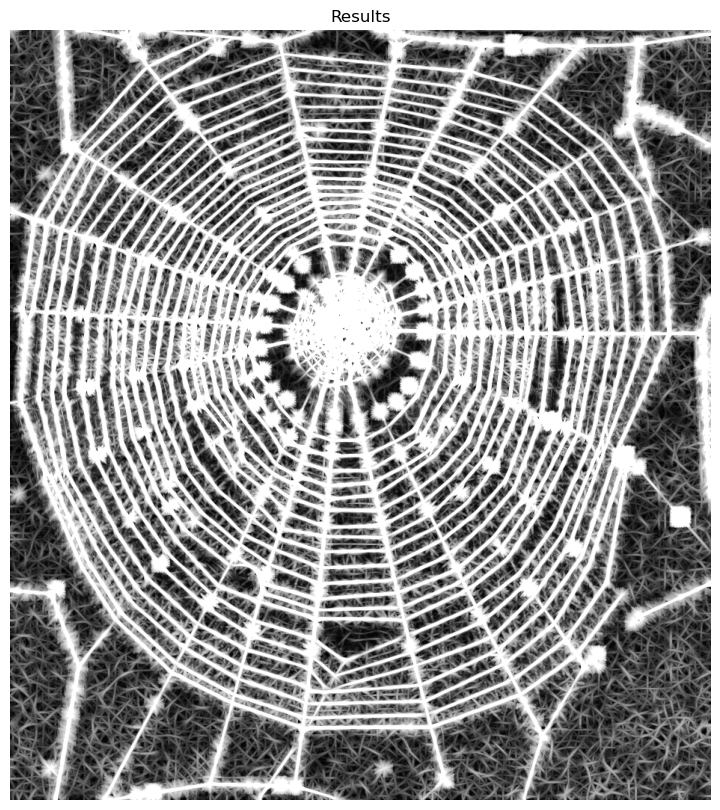

In [114]:
gray = cv2.cvtColor(all_images[0], cv2.COLOR_BGR2GRAY)
results = enhance_spider_web_smart2(gray)
imshow(results, "Results")

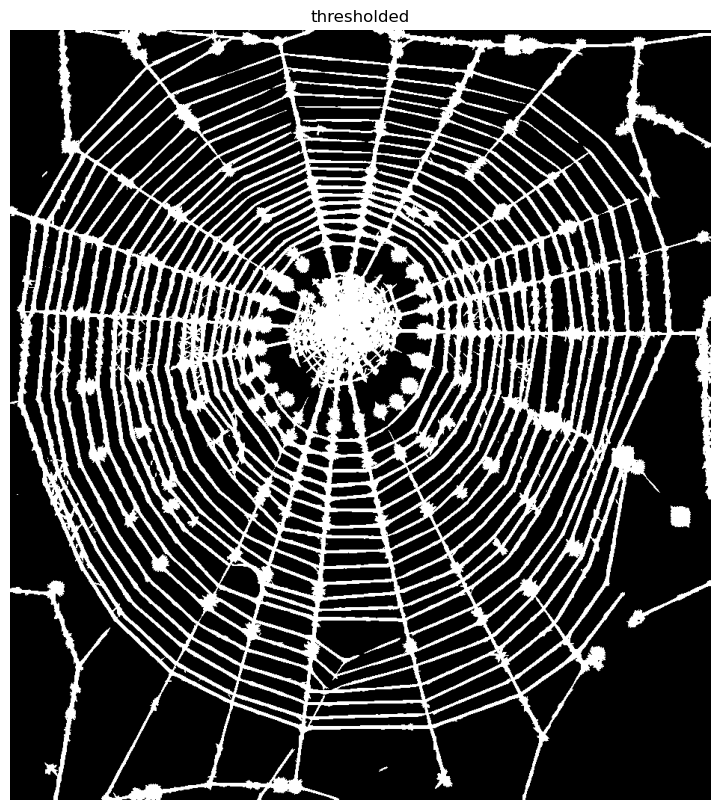

In [ ]:
_, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
imshow(edited, title = "thresholded")
#Try using the bright circles to your advantage. We know that they are they because web passes through them, so reconstruct radials passing through bright circles.Then calculate an average radius for the radials and get angle between them (might be easier)

In [8]:
def endpoint_direction(ep, edge_img):
    y, x = ep
    # Get gradients
    gx = cv2.Sobel(edge_img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(edge_img, cv2.CV_64F, 0, 1, ksize=3)
    dx, dy = gx[y, x], gy[y, x]
    norm = np.hypot(dx, dy) + 1e-8
    return np.array([dx / norm, dy / norm])


In [9]:
import cv2
import numpy as np
from scipy.ndimage import convolve
from scipy.spatial.distance import cdist

def find_endpoints(edge_img):
    kernel = np.array([[1,1,1],
                       [1,0,1],
                       [1,1,1]])
    neighbor_count = convolve(edge_img.astype(np.uint8), kernel, mode='constant', cval=0)
    endpoints = np.argwhere((edge_img > 0) & (neighbor_count <= 2))
    return endpoints



In [10]:
from scipy.spatial.distance import cdist

from sklearn.neighbors import NearestNeighbors

def connect_filtered_endpoints_fast(edges, max_dist=10, max_angle_deg=5):
    endpoints = find_endpoints(edges)
    if len(endpoints) < 2:
        return edges.copy()

    dirs = np.array([endpoint_direction(ep, edges) for ep in endpoints])
    connected = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    nbrs = NearestNeighbors(radius=max_dist, algorithm='kd_tree').fit(endpoints)
    pairs = nbrs.radius_neighbors(endpoints, return_distance=False)

    for i, neighbors in enumerate(pairs):
        for j in neighbors:
            if i >= j:
                continue  # avoid duplicates
            angle = np.degrees(np.arccos(np.clip(np.abs(np.dot(dirs[i], dirs[j])), 0, 1)))
            if angle <= max_angle_deg:
                pt1 = tuple(endpoints[i][::-1])
                pt2 = tuple(endpoints[j][::-1])
                cv2.line(connected, pt1, pt2, (0, 255, 0), 1)

    return connected


In [11]:
def plot_endpoints_on_image(edge_img, endpoints, color=(255, 0, 0), radius=3, thickness=-1):
    """
    Draws colored circles at endpoint locations on a color version of the edge image.
    Params:
    - edge_img: binary or grayscale edge image
    - endpoints: Nx2 array of (y, x) coordinates
    - color: BGR tuple for circle color (default blue)
    - radius: circle radius
    - thickness: -1 to fill circle
    
    Returns:
    - img_with_endpoints: color image with endpoints drawn
    """
    # Convert grayscale edge to BGR color image for colored drawing
    if len(edge_img.shape) == 2:
        img_color = cv2.cvtColor(edge_img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = edge_img.copy()

    for (y, x) in endpoints:
        cv2.circle(img_color, (x, y), radius, color, thickness)
    
    return img_color


Found 27 endpoints


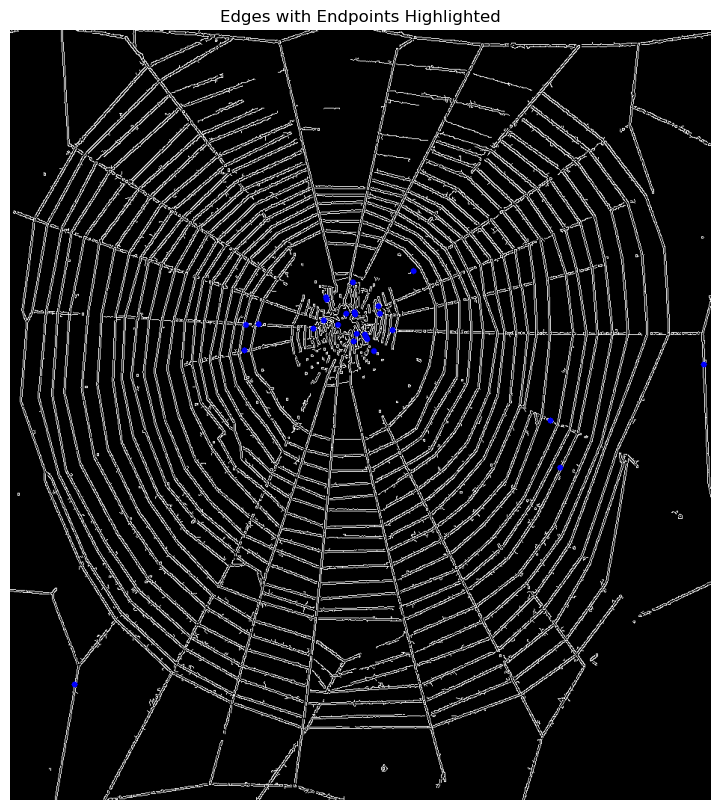

In [12]:
#Take a look at last chat with gpt about thinning out the webs.
endpoints = find_endpoints(edges)
print(f"Found {len(endpoints)} endpoints")

img_with_points = plot_endpoints_on_image(edges, endpoints, color=(0, 0, 255), radius=4)
imshow(img_with_points, "Edges with Endpoints Highlighted", cmap=None)

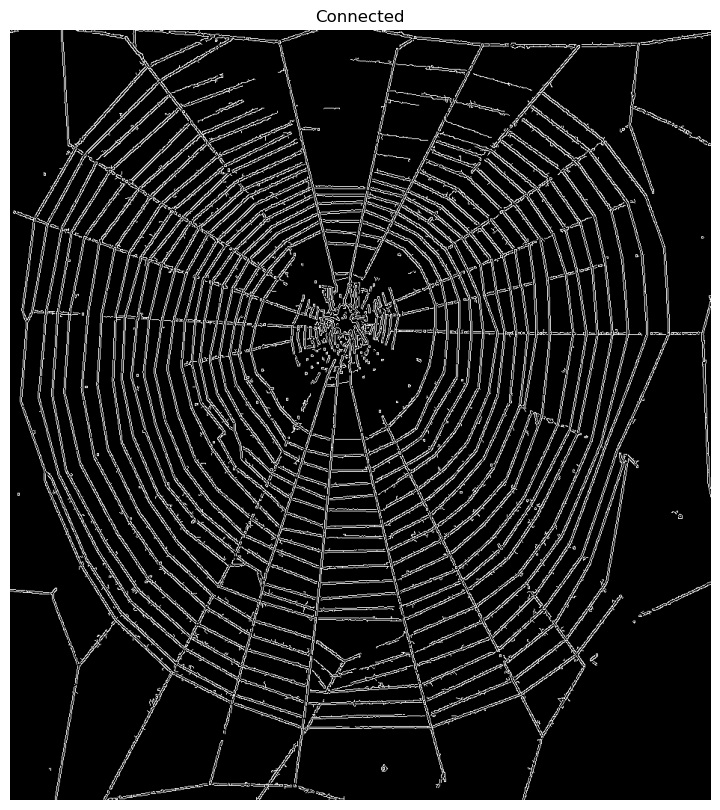

In [13]:
connected = connect_filtered_endpoints_fast(edges, max_dist= 5, max_angle_deg=15)
imshow(connected, title = "Connected")


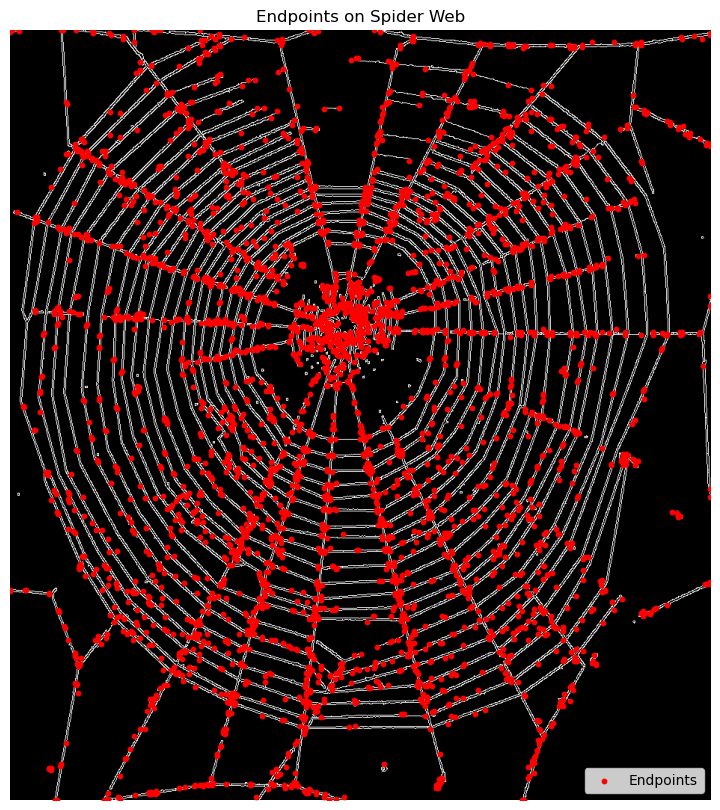

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import invert
from scipy.signal import convolve2d

# Skeletonize (skimage expects boolean image)
skeleton = skeletonize(edges > 0)

# Define endpoint detection kernel (8-connectivity)
kernel = np.array([[1, 1, 1],
                   [1, 10, 1],
                   [1, 1, 1]])

# Convolve to find pixels with only one neighbor (value = 11)
filtered = convolve2d(skeleton.astype(np.uint8), kernel, mode='same', boundary='fill', fillvalue=0)
endpoints = np.argwhere(filtered == 11)  # Coordinates: (row, col)

# Plot endpoints on the original image
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(edges, cmap='gray')
ax.scatter(endpoints[:, 1], endpoints[:, 0], s=10, c='red', label='Endpoints')
ax.set_title("Endpoints on Spider Web")
ax.axis('off')
plt.legend()
plt.show()

# Save coordinates if needed
np.savetxt("endpoints.csv", endpoints, delimiter=",", fmt="%d", header="y,x", comments="")


In [54]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.interpolate import UnivariateSpline
from sklearn.cluster import DBSCAN

def enhanced_web_reconstruction(skeleton, endpoints,
                               dist_thresh=50,
                               angle_thresh=10,
                               radius_thresh=15,
                               angle_sim_thresh=10,
                               linearity_thresh=15,
                               show=True):
    """
    Enhanced spider web reconstruction with improved radial and circular strand detection
    """
    
    def find_web_center(skeleton):
        """Improved center finding using intersection density"""
        coords = np.column_stack(np.nonzero(skeleton))
        if len(coords) == 0:
            raise ValueError("Skeleton image is empty or invalid.")
        
        # Create a grid to find intersection density
        h, w = skeleton.shape
        grid_size = 20
        best_center = None
        max_intersections = 0
        
        for y in range(grid_size, h - grid_size, grid_size):
            for x in range(grid_size, w - grid_size, grid_size):
                # Count skeleton points in local region
                local_region = skeleton[y-grid_size:y+grid_size, x-grid_size:x+grid_size]
                intersection_count = np.sum(local_region)
                
                if intersection_count > max_intersections:
                    max_intersections = intersection_count
                    best_center = (y, x)
        
        return best_center if best_center else tuple(int(v) for v in np.mean(coords, axis=0))
    
    def detect_radial_sectors(endpoints, center, n_sectors=8):
        """Divide the web into radial sectors for better analysis"""
        polar_coords = to_polar_coords(endpoints, center)
        sector_size = 360 / n_sectors
        sectors = {}
        
        for i, (r, theta) in enumerate(polar_coords):
            sector = int(theta // sector_size)
            if sector not in sectors:
                sectors[sector] = []
            sectors[sector].append((i, r, theta))
        
        return sectors
    
    def check_radial_alignment(p1, p2, center, tolerance_degrees=15):
        """Check if connection between two points is roughly radial from center"""
        # Vector from center to midpoint of connection
        mid_point = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
        center_to_mid = np.array([mid_point[0] - center[0], mid_point[1] - center[1]])
        
        # Vector of the connection itself
        connection_vector = np.array([p2[0] - p1[0], p2[1] - p1[1]])
        
        # Calculate angle between vectors
        if np.linalg.norm(center_to_mid) == 0 or np.linalg.norm(connection_vector) == 0:
            return False
            
        cos_angle = np.dot(center_to_mid, connection_vector) / (
            np.linalg.norm(center_to_mid) * np.linalg.norm(connection_vector))
        cos_angle = np.clip(cos_angle, -1, 1)
        angle_diff = np.degrees(np.arccos(abs(cos_angle)))
        
        # Connection should be roughly parallel to radial direction
        return angle_diff < tolerance_degrees

    def find_radial_path_segments(skeleton, center, angle, max_radius):
        """Find all skeleton segments along a specific radial direction"""
        segments = []
        angle_rad = np.radians(angle)
        
        # Cast rays from center outward and collect skeleton intersections
        for r in range(5, max_radius, 2):  # Sample every 2 pixels
            x = int(center[1] + r * np.cos(angle_rad))
            y = int(center[0] + r * np.sin(angle_rad))
            
            if 0 <= y < skeleton.shape[0] and 0 <= x < skeleton.shape[1]:
                # Check small neighborhood for skeleton points
                neighborhood_size = 3
                found_skeleton = False
                for dy in range(-neighborhood_size, neighborhood_size + 1):
                    for dx in range(-neighborhood_size, neighborhood_size + 1):
                        ny, nx = y + dy, x + dx
                        if (0 <= ny < skeleton.shape[0] and 0 <= nx < skeleton.shape[1] 
                            and skeleton[ny, nx]):
                            segments.append((ny, nx, r))
                            found_skeleton = True
                            break
                    if found_skeleton:
                        break
        
        return segments

    def reconstruct_central_radial_stubs(endpoints, center, sectors, skeleton, max_stub_radius=80):
        """Reconstruct broken radial strands near center by connecting stub endpoints"""
        central_connections = []
        center_radius = 30  # Points within this radius are considered central
        
        # Identify points near center
        polar_coords = to_polar_coords(endpoints, center)
        central_points = []
        
        for i, (r, theta) in enumerate(polar_coords):
            if r < center_radius:
                central_points.append((i, r, theta))
        
        # Group central points by angular sectors (finer resolution)
        n_fine_sectors = 16  # More sectors for better angular resolution
        fine_sector_size = 360 / n_fine_sectors
        fine_sectors = {}
        
        for point_idx, r, theta in central_points:
            sector = int(theta // fine_sector_size)
            if sector not in fine_sectors:
                fine_sectors[sector] = []
            fine_sectors[sector].append((point_idx, r, theta))
        
        # For each sector, try to connect points to form radial strands
        for sector_id, points in fine_sectors.items():
            if len(points) < 2:
                continue
            
            # Sort points by radius (closest to center first)
            points.sort(key=lambda x: x[1])
            
            # Try to connect consecutive points if they form a reasonable radial pattern
            for i in range(len(points) - 1):
                curr_idx, curr_r, curr_theta = points[i]
                next_idx, next_r, next_theta = points[i + 1]
                
                # Check angular alignment
                angle_diff = abs(curr_theta - next_theta)
                if angle_diff > 180:
                    angle_diff = 360 - angle_diff
                
                if angle_diff < 20:  # Points are roughly in same angular direction
                    # Check if connection is radially aligned
                    if check_radial_alignment(endpoints[curr_idx], endpoints[next_idx], center, 25):
                        # Check distance is reasonable
                        dist = np.linalg.norm(endpoints[curr_idx] - endpoints[next_idx])
                        if 5 < dist < max_stub_radius:
                            central_connections.append((curr_idx, next_idx, 'central_radial_stub'))
        
        # Also try to connect central stubs to nearby outer points
        outer_connections = []
        for point_idx, r, theta in central_points:
            # Find nearby points in same angular direction but at larger radius
            for i, (outer_r, outer_theta) in enumerate(polar_coords):
                if i == point_idx:
                    continue
                    
                # Check if in similar angular direction
                angle_diff = abs(theta - outer_theta)
                if angle_diff > 180:
                    angle_diff = 360 - angle_diff
                
                if angle_diff < 15 and outer_r > r + 20:  # Further out and aligned
                    dist = np.linalg.norm(endpoints[point_idx] - endpoints[i])
                    if dist < max_stub_radius:
                        # Check radial alignment
                        if check_radial_alignment(endpoints[point_idx], endpoints[i], center, 20):
                            # Verify there's skeleton support
                            if validate_skeleton_path(skeleton, endpoints[point_idx], endpoints[i], tolerance=5):
                                outer_connections.append((point_idx, i, 'stub_to_outer'))
        
        return central_connections + outer_connections

    def is_perpendicular_to_radials(p1, p2, center, nearby_radials, tolerance_degrees=25):
        """Check if circular connection is roughly perpendicular to nearby radial lines"""
        # Calculate midpoint of circular connection
        mid_point = np.array([(p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2])
        
        # Vector of the circular connection
        circular_vector = np.array([p2[0] - p1[0], p2[1] - p1[1]])
        circular_angle = np.degrees(np.arctan2(circular_vector[0], circular_vector[1])) % 360
        
        # Check angles with nearby radial lines
        perpendicular_count = 0
        total_checks = 0
        
        for radial_connection in nearby_radials:
            if len(radial_connection) >= 2:
                r_i, r_j = radial_connection[0], radial_connection[1]
                
                # Check if radial line is near our circular connection
                radial_p1, radial_p2 = endpoints[r_i], endpoints[r_j]
                
                # Distance from midpoint to radial line
                dist_to_radial = point_to_line_distance(mid_point, radial_p1, radial_p2)
                
                if dist_to_radial < 50:  # Radial is nearby
                    total_checks += 1
                    
                    # Calculate radial angle
                    radial_vector = np.array([radial_p2[0] - radial_p1[0], radial_p2[1] - radial_p1[1]])
                    radial_angle = np.degrees(np.arctan2(radial_vector[0], radial_vector[1])) % 360
                    
                    # Check if roughly perpendicular
                    angle_diff = abs(circular_angle - radial_angle)
                    angle_diff = min(angle_diff, 360 - angle_diff)
                    perpendicular_diff = abs(angle_diff - 90)
                    
                    if perpendicular_diff < tolerance_degrees:
                        perpendicular_count += 1
        
        # Require that at least 70% of nearby radials are perpendicular
        if total_checks == 0:
            return True  # No nearby radials to check against
        
        return (perpendicular_count / total_checks) >= 0.7

    def point_to_line_distance(point, line_p1, line_p2):
        """Calculate distance from point to line segment"""
        # Vector from line_p1 to line_p2
        line_vec = line_p2 - line_p1
        # Vector from line_p1 to point
        point_vec = point - line_p1
        
        # Project point_vec onto line_vec
        line_len = np.linalg.norm(line_vec)
        if line_len == 0:
            return np.linalg.norm(point_vec)
        
        line_unitvec = line_vec / line_len
        proj_length = np.dot(point_vec, line_unitvec)
        
        # Clamp projection to line segment
        proj_length = max(0, min(proj_length, line_len))
        
        # Find closest point on line
        closest_point = line_p1 + proj_length * line_unitvec
        
        # Return distance
        return np.linalg.norm(point - closest_point)

    def filter_circular_connections(circular_candidates, radial_lines, center, endpoints):
        """Filter circular connections to ensure they're perpendicular to radials"""
        filtered_circular = []
        
        for connection in circular_candidates:
            i, j = connection[0], connection[1]
            p1, p2 = endpoints[i], endpoints[j]
            
            # Check perpendicularity to nearby radials
            if is_perpendicular_to_radials(p1, p2, center, radial_lines):
                filtered_circular.append(connection)
            else:
                # Optionally mark as rejected for debugging
                if len(connection) == 3:
                    filtered_circular.append((i, j, connection[2] + '_rejected'))
        
        return filtered_circular

    def connect_radial_segments(sectors, center, skeleton):
        """Connect broken radial segments by following skeleton paths"""
        missing_connections = []
        h, w = skeleton.shape
        max_radius = min(h, w) // 2
        
        # For each sector, analyze the radial pattern
        for sector_id, points in sectors.items():
            if len(points) < 1:
                continue
            
            # Calculate the main angle for this sector
            sector_angle = sector_id * (360 / 8)  # 8 sectors
            
            # Find all skeleton segments along this radial direction
            radial_segments = find_radial_path_segments(skeleton, center, sector_angle, max_radius)
            
            if len(radial_segments) < 2:
                continue
            
            # Group segments by proximity
            segment_groups = []
            for seg_y, seg_x, seg_r in radial_segments:
                # Find closest endpoints to this segment
                distances = [np.linalg.norm(np.array([seg_y, seg_x]) - ep) for ep in endpoints]
                min_dist_idx = np.argmin(distances)
                
                if distances[min_dist_idx] < 10:  # Close enough to an endpoint
                    segment_groups.append((min_dist_idx, seg_r))
            
            # Sort by radius and connect gaps
            segment_groups.sort(key=lambda x: x[1])
            for i in range(len(segment_groups) - 1):
                idx1, r1 = segment_groups[i]
                idx2, r2 = segment_groups[i + 1]
                
                # Check if there's a gap that needs filling
                if 15 < r2 - r1 < 100 and check_radial_alignment(endpoints[idx1], endpoints[idx2], center):
                    missing_connections.append((idx1, idx2, 'radial_segment_bridge'))
        
        return missing_connections
    
    def detect_circular_patterns(endpoints, center):
        """Enhanced circular pattern detection using radius clustering"""
        polar_coords = to_polar_coords(endpoints, center)
        radii = polar_coords[:, 0].reshape(-1, 1)
        
        # Cluster endpoints by radius
        clustering = DBSCAN(eps=20, min_samples=3).fit(radii)
        labels = clustering.labels_
        
        circular_groups = {}
        for i, label in enumerate(labels):
            if label != -1:  # Not noise
                if label not in circular_groups:
                    circular_groups[label] = []
                circular_groups[label].append(i)
        
        return circular_groups
    
    def trace_circular_path(skeleton, start_point, end_point, center, radius_tolerance=10):
        """Trace along skeleton to connect circular arc segments"""
        # Use A* or simple path following along skeleton
        start_y, start_x = start_point
        end_y, end_x = end_point
        
        # Calculate expected radius
        expected_radius = np.linalg.norm(np.array(start_point) - np.array(center))
        
        # Simple path tracing using breadth-first search along skeleton
        from collections import deque
        queue = deque([(start_y, start_x, [(start_y, start_x)])])
        visited = set()
        visited.add((start_y, start_x))
        
        directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
        
        while queue:
            y, x, path = queue.popleft()
            
            # Check if we reached the target
            if (y, x) == (end_y, end_x):
                return path
            
            # If path is getting too long, abandon
            if len(path) > 50:
                break
            
            # Explore neighbors
            for dy, dx in directions:
                ny, nx = y + dy, x + dx
                
                if (0 <= ny < skeleton.shape[0] and 0 <= nx < skeleton.shape[1] 
                    and (ny, nx) not in visited and skeleton[ny, nx]):
                    
                    # Check if this point is roughly at the expected radius
                    point_radius = np.linalg.norm(np.array([ny, nx]) - np.array(center))
                    if abs(point_radius - expected_radius) < radius_tolerance:
                        visited.add((ny, nx))
                        queue.append((ny, nx, path + [(ny, nx)]))
        
        return None  # No path found

    def reconstruct_circular_arcs(circular_groups, endpoints, center, skeleton):
        """Reconstruct missing circular connections by following skeleton paths"""
        missing_circular = []
        
        for group_id, point_indices in circular_groups.items():
            if len(point_indices) < 2:
                continue
            
            # Get polar coordinates for this radius group
            group_points = endpoints[point_indices]
            polar_coords = to_polar_coords(group_points, center)
            angles = polar_coords[:, 1]
            avg_radius = np.mean(polar_coords[:, 0])
            
            # Sort by angle
            sorted_indices = np.argsort(angles)
            sorted_angles = angles[sorted_indices]
            
            # Find gaps in the circular pattern and try to bridge them
            for i in range(len(sorted_angles)):
                current_idx = point_indices[sorted_indices[i]]
                next_idx = point_indices[sorted_indices[(i + 1) % len(sorted_indices)]]
                
                current_angle = sorted_angles[i]
                next_angle = sorted_angles[(i + 1) % len(sorted_angles)]
                
                # Calculate angular gap (handle wraparound)
                if i == len(sorted_angles) - 1:  # Last to first
                    angle_gap = (sorted_angles[0] + 360) - current_angle
                else:
                    angle_gap = next_angle - current_angle
                
                # Check if connection is tangential and gap is reasonable
                if is_tangential_connection(endpoints[current_idx], endpoints[next_idx], center):
                    if 15 < angle_gap < 120:  # Reasonable arc segment
                        # Try to trace path along skeleton
                        path = trace_circular_path(skeleton, endpoints[current_idx], 
                                                 endpoints[next_idx], center)
                        
                        if path is not None:
                            missing_circular.append((current_idx, next_idx, 'circular_traced'))
                        elif angle_gap < 60:  # Only infer short gaps
                            missing_circular.append((current_idx, next_idx, 'circular_inferred'))
        
        return missing_circular
    
    def is_tangential_connection(p1, p2, center, tolerance_degrees=25):
        """Check if connection between two points is roughly tangential to circle"""
        # Midpoint of connection
        mid_point = np.array([(p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2])
        
        # Radial vector from center to midpoint
        radial_vector = mid_point - np.array(center)
        
        # Connection vector
        connection_vector = np.array([p2[0] - p1[0], p2[1] - p1[1]])
        
        if np.linalg.norm(radial_vector) == 0 or np.linalg.norm(connection_vector) == 0:
            return False
        
        # Calculate angle between radial and connection vectors
        cos_angle = np.dot(radial_vector, connection_vector) / (
            np.linalg.norm(radial_vector) * np.linalg.norm(connection_vector))
        cos_angle = np.clip(cos_angle, -1, 1)
        angle = np.degrees(np.arccos(abs(cos_angle)))
        
        # For tangential connection, angle should be close to 90 degrees
        return abs(angle - 90) < tolerance_degrees
    
    def validate_skeleton_path(skeleton, p1, p2, tolerance=3):
        """Check if a path between two points follows existing skeleton"""
        y1, x1 = p1
        y2, x2 = p2
        
        # Generate line points
        num_points = max(abs(x2 - x1), abs(y2 - y1))
        if num_points == 0:
            return True
            
        x_points = np.linspace(x1, x2, num_points).astype(int)
        y_points = np.linspace(y1, y2, num_points).astype(int)
        
        # Check if path follows skeleton (with some tolerance)
        skeleton_support = 0
        for x, y in zip(x_points, y_points):
            if 0 <= y < skeleton.shape[0] and 0 <= x < skeleton.shape[1]:
                # Check in a small neighborhood
                neighborhood = skeleton[max(0, y-tolerance):y+tolerance+1,
                                     max(0, x-tolerance):x+tolerance+1]
                if np.any(neighborhood):
                    skeleton_support += 1
        
        support_ratio = skeleton_support / num_points
        return support_ratio > 0.3  # At least 30% support
    
    def to_polar_coords(points, center):
        shifted = points - center
        x, y = shifted[:, 1], shifted[:, 0]
        r = np.sqrt(x**2 + y**2)
        theta = np.degrees(np.arctan2(y, x)) % 360
        return np.column_stack((r, theta))

    def compute_connection_angle(p1, p2):
        dy, dx = p2[0] - p1[0], p2[1] - p1[1]
        return np.degrees(np.arctan2(dy, dx)) % 180

    def angle_difference(a1, a2):
        diff = abs(a1 - a2)
        return min(diff, 180 - diff)

    def estimate_endpoint_angle(skel, point, window_size=7):
        """Enhanced angle estimation with larger window"""
        y, x = point
        half_w = window_size // 2
        patch = skel[max(0, y - half_w): y + half_w + 1,
                     max(0, x - half_w): x + half_w + 1]
        ys, xs = np.where(patch)
        if len(ys) < 2:
            return 999
        ys = ys - half_w
        xs = xs - half_w
        coords = np.column_stack((ys, xs))
        mean = np.mean(coords, axis=0)
        coords_centered = coords - mean
        cov = np.cov(coords_centered, rowvar=False)
        if np.linalg.det(cov) == 0:
            return 999
        eigvals, eigvecs = np.linalg.eigh(cov)
        principal_vector = eigvecs[:, np.argmax(eigvals)]
        angle = np.degrees(np.arctan2(principal_vector[0], principal_vector[1])) % 180
        return angle

    def draw_enhanced_lines(lines, color, title, line_width=2):
        img = cv2.cvtColor((skeleton * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        
        for connection in lines:
            if len(connection) == 2:  # Original format
                i, j = connection
                connection_type = ""
            else:  # Enhanced format with metadata
                i, j, connection_type = connection
                
            y1, x1 = endpoints[i]
            y2, x2 = endpoints[j]
            
            # Use different line styles for rejected connections
            if 'rejected' in connection_type:
                # Draw rejected connections as dashed lines (approximate with shorter segments)
                cv2.line(img, (x1, y1), (x2, y2), (128, 128, 128), 1)
            else:
                cv2.line(img, (x1, y1), (x2, y2), color, line_width)
            
            # Add connection type annotation if available
            if connection_type and not 'rejected' in connection_type:
                mid_x, mid_y = (x1 + x2) // 2, (y1 + y2) // 2
                cv2.putText(img, connection_type[:4], (mid_x, mid_y), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)
        
        if show:
            plt.figure(figsize=(12, 12))
            plt.imshow(img)
            plt.title(title)
            plt.axis('off')
            plt.show()
        return img

    # Main processing
    center = find_web_center(skeleton)
    angles = np.array([estimate_endpoint_angle(skeleton, pt) for pt in endpoints])
    polar_coords = to_polar_coords(endpoints, center)
    
    # Enhanced sector-based analysis
    sectors = detect_radial_sectors(endpoints, center)
    circular_groups = detect_circular_patterns(endpoints, center)
    
    # Original connection detection with enhanced filtering
    radial_lines = []
    circular_candidates = []
    
    for i in range(len(endpoints)):
        for j in range(i + 1, len(endpoints)):
            dist = np.linalg.norm(endpoints[i] - endpoints[j])
            if dist > dist_thresh:
                continue

            a1, a2 = angles[i], angles[j]
            if a1 == 999 or a2 == 999:
                continue

            if angle_difference(a1, a2) > angle_sim_thresh:
                continue

            conn_angle = compute_connection_angle(endpoints[i], endpoints[j])
            if (angle_difference(a1, conn_angle) > linearity_thresh or
                angle_difference(a2, conn_angle) > linearity_thresh):
                continue

            r1, t1 = polar_coords[i]
            r2, t2 = polar_coords[j]

            # Enhanced radial detection with strict alignment check
            if abs(t1 - t2) < angle_thresh:
                # Additional check: ensure connection is radially aligned
                if check_radial_alignment(endpoints[i], endpoints[j], center):
                    if validate_skeleton_path(skeleton, endpoints[i], endpoints[j]):
                        radial_lines.append((i, j, 'radial_validated'))
                    else:
                        radial_lines.append((i, j, 'radial_inferred'))
            
            # Enhanced circular detection with tangential check
            elif abs(r1 - r2) < radius_thresh:
                # Additional check: ensure connection is tangential
                if is_tangential_connection(endpoints[i], endpoints[j], center):
                    if validate_skeleton_path(skeleton, endpoints[i], endpoints[j]):
                        circular_candidates.append((i, j, 'circular_validated'))
                    else:
                        circular_candidates.append((i, j, 'circular_inferred'))
    
    # Add reconstructed connections
    missing_radial = connect_radial_segments(sectors, center, skeleton)
    central_radial_stubs = reconstruct_central_radial_stubs(endpoints, center, sectors, skeleton)
    missing_circular = reconstruct_circular_arcs(circular_groups, endpoints, center, skeleton)
    
    # Combine radial connections first
    all_radial = radial_lines + missing_radial + central_radial_stubs
    
    # Filter circular connections based on perpendicularity to radials
    all_circular_candidates = circular_candidates + missing_circular
    filtered_circular = filter_circular_connections(all_circular_candidates, all_radial, center, endpoints)
    
    # Generate visualizations
    img_radial = draw_enhanced_lines(all_radial, (0, 255, 0), 
                                   "Enhanced Radial Connections", 2)
    img_circular = draw_enhanced_lines(filtered_circular, (255, 0, 0), 
                                     "Enhanced Circular Connections", 2)
    
    # Combined visualization
    img_combined = cv2.cvtColor((skeleton * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    
    # Draw all connections (only non-rejected ones)
    for connection in all_radial:
        i, j = connection[0], connection[1]
        y1, x1 = endpoints[i]
        y2, x2 = endpoints[j]
        cv2.line(img_combined, (x1, y1), (x2, y2), (0, 255, 0), 1)
    
    for connection in filtered_circular:
        if len(connection) < 3 or 'rejected' not in connection[2]:
            i, j = connection[0], connection[1]
            y1, x1 = endpoints[i]
            y2, x2 = endpoints[j]
            cv2.line(img_combined, (x1, y1), (x2, y2), (255, 0, 0), 1)
    
    # Mark center
    cv2.circle(img_combined, (center[1], center[0]), 5, (255, 255, 0), -1)
    
    if show:
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img_radial)
        plt.title("Radial Connections")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(img_circular)
        plt.title("Circular Connections")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(img_combined)
        plt.title("Combined Reconstruction")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return {
        "img_radial": img_radial,
        "img_circular": img_circular,
        "img_combined": img_combined,
    }

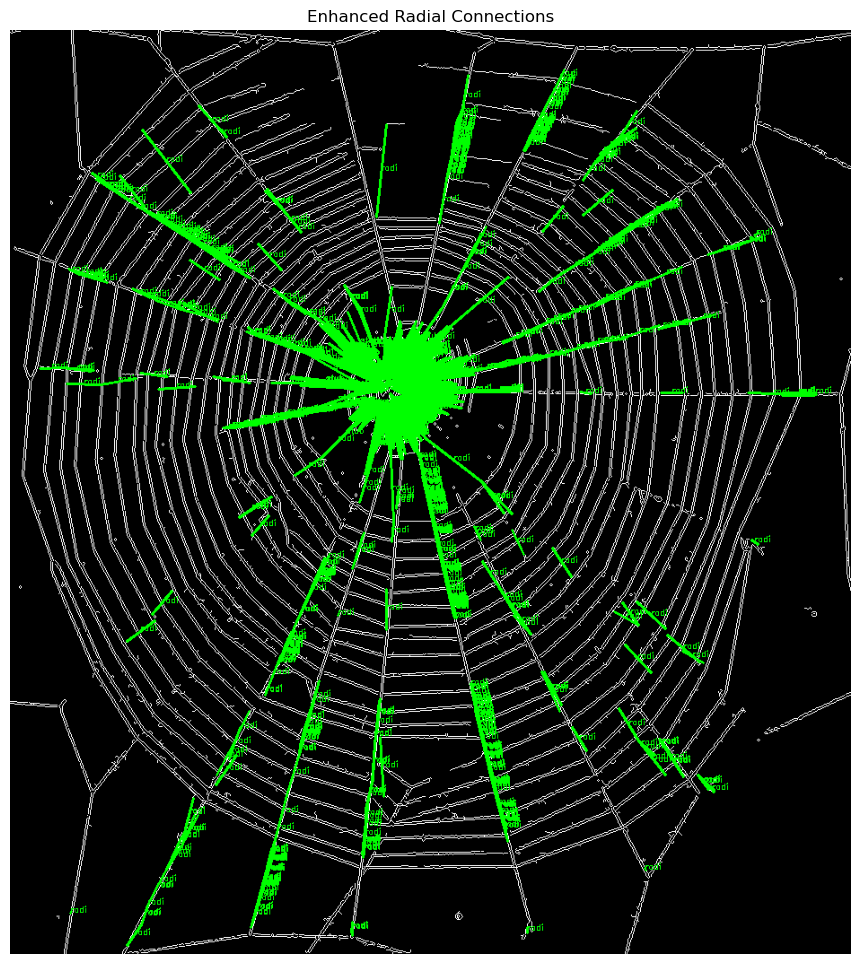

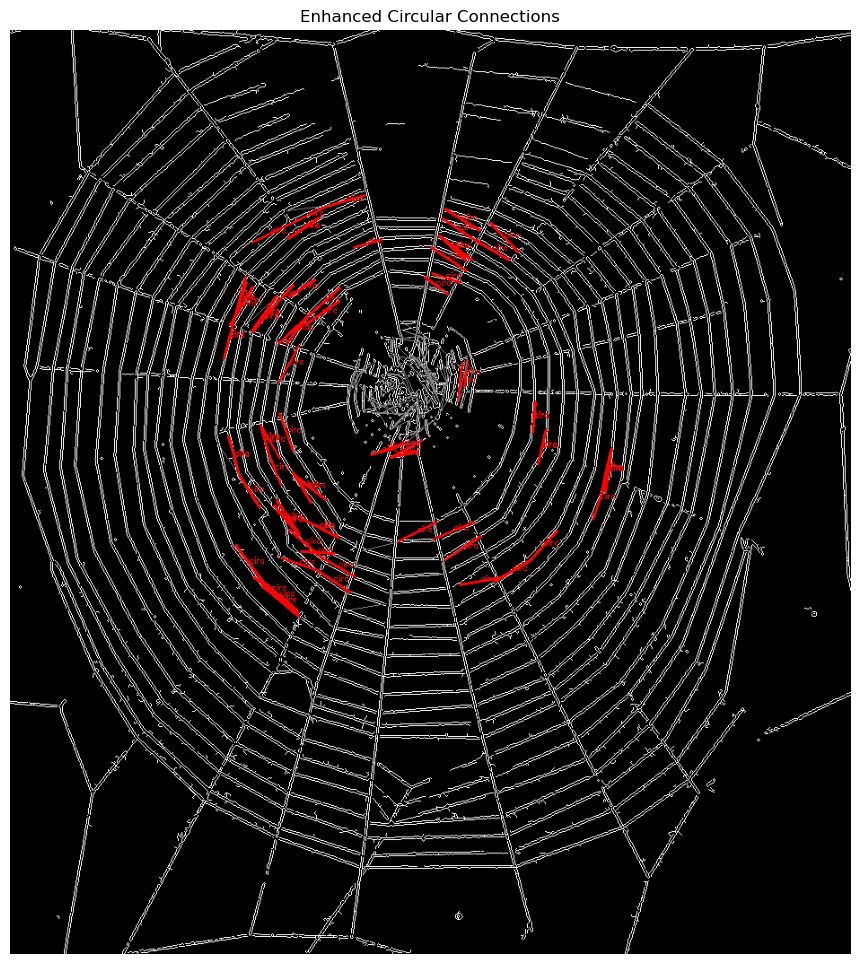

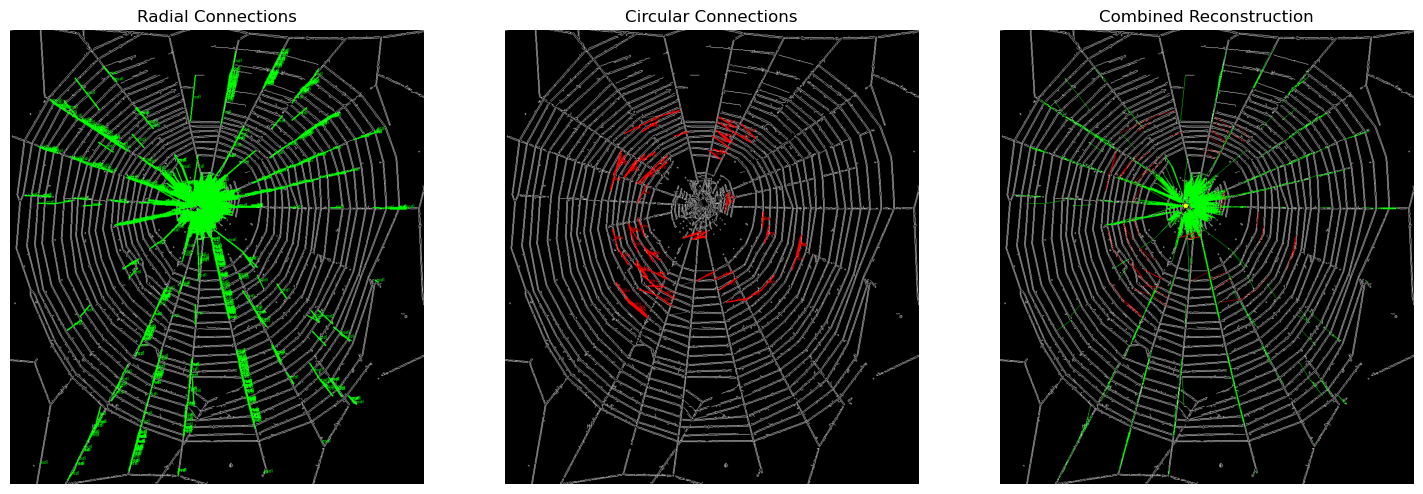

In [55]:
radial, circular, combined = enhanced_web_reconstruction(skeleton, endpoints)

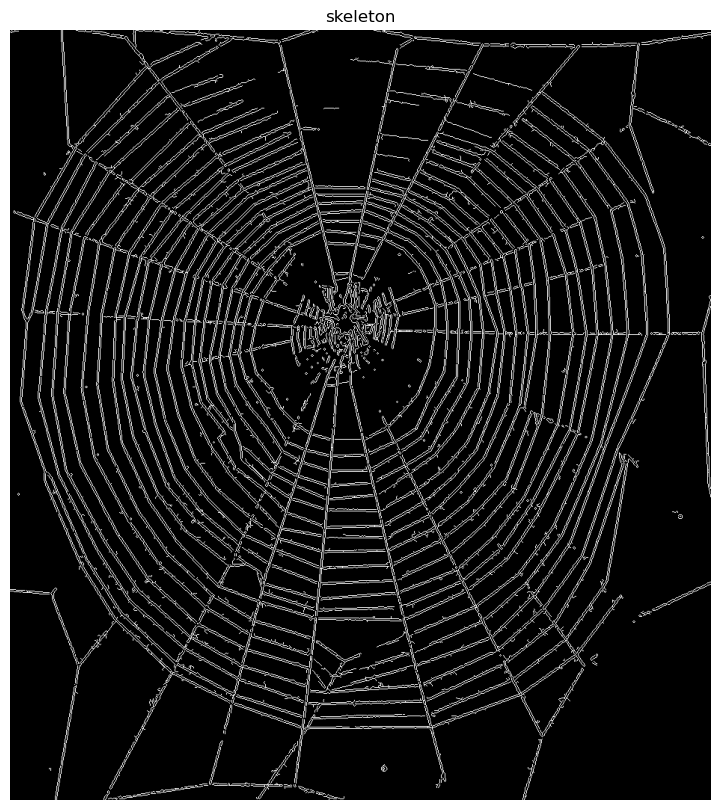

In [47]:
imshow(skeleton, title= 'skeleton')